In [1]:
import os
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Configuration

Define paths and parameters for the experiment.

In [2]:
# Graphs to download and benchmark
graphs = ",".join([
    # Road Networks
    "road-luxembourg-osm",
    "road-usroads-48",
    "road-roadNet-PA",
    # Triangulations / Geometric
    "delaunay_n17",
    "delaunay_n18",
    "delaunay_n20",
    # Social / Collaboration
    "soc-LiveMocha",
    "ca-MathSciNet",
    "soc-lastfm",
])

# Directory for storing benchmark results
results_dir = "results"

# Directory containing graph files
graphs_dir = r"..\graphs"

## Step 1. Download selected graphs

We download the selected road, geometric, and social-like graphs into `../graphs` using the shared downloader script.

In [3]:
!python {graphs_dir}\download_graphs.py {graphs} --dir {graphs_dir}

=== Downloading 9 graph(s) to '..\graphs' ===
  [DOWNLOAD] road-luxembourg-osm...
  [OK] road-luxembourg-osm.mtx
    preview:
      %%MatrixMarket matrix coordinate pattern symmetric
      %-------------------------------------------------------------------------------
      % UF Sparse Matrix Collection, Tim Davis
      % http://www.cise.ufl.edu/research/sparse/matrices/DIMACS10/luxembourg_osm
      % name: DIMACS10/luxembourg_osm
  [DOWNLOAD] road-usroads-48...
  [OK] road-usroads-48.mtx
    preview:
      %%MatrixMarket matrix coordinate pattern symmetric
      %-------------------------------------------------------------------------------
      % UF Sparse Matrix Collection, Tim Davis
      % http://www.cise.ufl.edu/research/sparse/matrices/Gleich/usroads-48
      % name: Gleich/usroads-48
  [DOWNLOAD] road-roadNet-PA...
  [OK] road-roadNet-PA.mtx
    preview:
      %MatrixMarket matrix coordinate pattern symmetric
      1087562 1087562 1541514
      2 1
      6299 1
      6343 1


## Step 2. Add weights to graphs

SPLA implementation requires weighted edges in MTX format.
This step adds weights to pattern graphs using the formula: `weight = min(src, dst)`.

- Creates backup files (`.mtx.bak`) on first run
- Skips already processed files (if backup exists)
- Safe to re-run multiple times

In [4]:
!cd {graphs_dir} && python add_weights.py {graphs}

[OK] road-luxembourg-osm.mtx.bak -> road-luxembourg-osm.mtx (119666 edges)
[OK] road-usroads-48.mtx.bak -> road-usroads-48.mtx (161950 edges)
[OK] road-roadNet-PA.mtx.bak -> road-roadNet-PA.mtx (1541514 edges)
[OK] delaunay_n17.mtx.bak -> delaunay_n17.mtx (393176 edges)
[OK] delaunay_n18.mtx.bak -> delaunay_n18.mtx (786396 edges)
[OK] delaunay_n20.mtx.bak -> delaunay_n20.mtx (3145686 edges)
[OK] soc-LiveMocha.mtx.bak -> soc-LiveMocha.mtx (2193083 edges)
[OK] ca-MathSciNet.mtx.bak -> ca-MathSciNet.mtx (820644 edges)
[OK] soc-lastfm.mtx.bak -> soc-lastfm.mtx (4519330 edges)


## Step 3. Create results directory

Create a directory for storing benchmark results (CSV files, logs, etc.).

- If `results_dir` is a relative path, it will be interpreted relative to the current notebook working directory.
- If the directory already exists, it will not be modified.
- If the directory does not exist, it will be created (including any necessary parent directories).

In [5]:
results_path = Path(results_dir)

# If path is relative, interpret it relative to current notebook working directory
if not results_path.is_absolute():
    results_path = Path.cwd() / results_path

# Create directory only if it does not exist
results_path.mkdir(parents=True, exist_ok=True)

print(f"Results directory: {results_path}")
print(f"Exists: {results_path.exists()}")

Results directory: c:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\experiment_graph_types\results
Exists: True


## Step 4. Run Spark benchmarks

Run Boruvka MST algorithm on Spark for each graph.

Parameters:
- `warmup = 3` — number of warmup runs (JIT compilation, class loading)
- `runs = 10` — number of benchmark runs
- `cores = 1` — single-threaded execution for fair comparison

Each graph runs in a separate cell to allow partial re-execution if needed.

In [42]:
# Benchmark parameters
warmup = 3
runs = 5
cores = 1

# Paths
spark_project_dir = r"..\boruvka_spark"

### Road Networks

In [43]:
!cd {spark_project_dir} && sbt "run --graph={graphs_dir}\road-luxembourg-osm.mtx --csv={results_path}\spark_road-luxembourg-osm.csv --runs={runs} --warmup={warmup} --cores={cores}"

env: OpenCL Acc Intel(R) OpenCL Graphics device: Intel(R) Iris(R) Xe Graphics vendor:intel mcu:80 wave:8 mwgs:512
[info] welcome to sbt 1.9.7 (Eclipse Adoptium Java 11.0.30)
[info] loading project definition from C:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\boruvka_spark\project
[info] loading settings for project root from build.sbt ...
[info] set current project to boruvka_spark (in build file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/)
[info] running (fork) boruvka.Main --graph=..\graphs\road-luxembourg-osm.mtx --csv=c:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\experiment_graph_types\results\spark_road-luxembourg-osm.csv --runs=5 --warmup=3 --cores=1
[error] WARNING: An illegal reflective access operation has occurred
[error] WARNING: Illegal reflective access by org.apache.spark.unsafe.Platform (file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/target/bg-jobs/sbt_4c33e0ea/target/40f64c8b/8e672e

In [44]:
!cd {spark_project_dir} && sbt "run --graph={graphs_dir}\road-usroads-48.mtx --csv={results_path}\spark_road-usroads-48.csv --runs={runs} --warmup={warmup} --cores={cores}"

[info] welcome to sbt 1.9.7 (Eclipse Adoptium Java 11.0.30)
[info] loading project definition from C:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\boruvka_spark\project
[info] loading settings for project root from build.sbt ...
[info] set current project to boruvka_spark (in build file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/)
[info] running (fork) boruvka.Main --graph=..\graphs\road-usroads-48.mtx --csv=c:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\experiment_graph_types\results\spark_road-usroads-48.csv --runs=5 --warmup=3 --cores=1
[error] WARNING: An illegal reflective access operation has occurred
[error] WARNING: Illegal reflective access by org.apache.spark.unsafe.Platform (file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/target/bg-jobs/sbt_3fd2897/target/40f64c8b/8e672e72/spark-unsafe_2.12-3.5.1.jar) to constructor java.nio.DirectByteBuffer(long,int)
[error] WARNING: Please consider reporti

In [45]:
!cd {spark_project_dir} && sbt "run --graph={graphs_dir}\road-roadNet-PA.mtx --csv={results_path}\spark_road-roadNet-PA.csv --runs={runs} --warmup={warmup} --cores={cores}"

[info] welcome to sbt 1.9.7 (Eclipse Adoptium Java 11.0.30)
[info] loading project definition from C:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\boruvka_spark\project
[info] loading settings for project root from build.sbt ...
[info] set current project to boruvka_spark (in build file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/)
[info] running (fork) boruvka.Main --graph=..\graphs\road-roadNet-PA.mtx --csv=c:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\experiment_graph_types\results\spark_road-roadNet-PA.csv --runs=5 --warmup=3 --cores=1
[error] WARNING: An illegal reflective access operation has occurred
[error] WARNING: Illegal reflective access by org.apache.spark.unsafe.Platform (file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/target/bg-jobs/sbt_a07cdf00/target/40f64c8b/8e672e72/spark-unsafe_2.12-3.5.1.jar) to constructor java.nio.DirectByteBuffer(long,int)
[error] WARNING: Please consider report

### Triangulations / Geometric

In [46]:
!cd {spark_project_dir} && sbt "run --graph={graphs_dir}\delaunay_n17.mtx --csv={results_path}\spark_delaunay_n17.csv --runs={runs} --warmup={warmup} --cores={cores}"

[info] welcome to sbt 1.9.7 (Eclipse Adoptium Java 11.0.30)
[info] loading project definition from C:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\boruvka_spark\project
[info] loading settings for project root from build.sbt ...
[info] set current project to boruvka_spark (in build file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/)
[info] running (fork) boruvka.Main --graph=..\graphs\delaunay_n17.mtx --csv=c:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\experiment_graph_types\results\spark_delaunay_n17.csv --runs=5 --warmup=3 --cores=1
[error] WARNING: An illegal reflective access operation has occurred
[error] WARNING: Illegal reflective access by org.apache.spark.unsafe.Platform (file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/target/bg-jobs/sbt_5748780a/target/40f64c8b/8e672e72/spark-unsafe_2.12-3.5.1.jar) to constructor java.nio.DirectByteBuffer(long,int)
[error] WARNING: Please consider reporting th

In [47]:
!cd {spark_project_dir} && sbt "run --graph={graphs_dir}\delaunay_n18.mtx --csv={results_path}\spark_delaunay_n18.csv --runs={runs} --warmup={warmup} --cores={cores}"

[info] welcome to sbt 1.9.7 (Eclipse Adoptium Java 11.0.30)
[info] loading project definition from C:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\boruvka_spark\project
[info] loading settings for project root from build.sbt ...
[info] set current project to boruvka_spark (in build file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/)
[info] running (fork) boruvka.Main --graph=..\graphs\delaunay_n18.mtx --csv=c:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\experiment_graph_types\results\spark_delaunay_n18.csv --runs=5 --warmup=3 --cores=1
[error] WARNING: An illegal reflective access operation has occurred
[error] WARNING: Illegal reflective access by org.apache.spark.unsafe.Platform (file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/target/bg-jobs/sbt_63070755/target/40f64c8b/8e672e72/spark-unsafe_2.12-3.5.1.jar) to constructor java.nio.DirectByteBuffer(long,int)
[error] WARNING: Please consider reporting th

In [48]:
!cd {spark_project_dir} && sbt "run --graph={graphs_dir}\delaunay_n20.mtx --csv={results_path}\spark_delaunay_n20.csv --runs={runs} --warmup={warmup} --cores={cores}"

[info] welcome to sbt 1.9.7 (Eclipse Adoptium Java 11.0.30)
[info] loading project definition from C:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\boruvka_spark\project
[info] loading settings for project root from build.sbt ...
[info] set current project to boruvka_spark (in build file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/)
[info] running (fork) boruvka.Main --graph=..\graphs\delaunay_n20.mtx --csv=c:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\experiment_graph_types\results\spark_delaunay_n20.csv --runs=5 --warmup=3 --cores=1
[error] WARNING: An illegal reflective access operation has occurred
[error] WARNING: Illegal reflective access by org.apache.spark.unsafe.Platform (file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/target/bg-jobs/sbt_8187c6e7/target/40f64c8b/8e672e72/spark-unsafe_2.12-3.5.1.jar) to constructor java.nio.DirectByteBuffer(long,int)
[error] WARNING: Please consider reporting th

### Social / Collaboration

In [49]:
!cd {spark_project_dir} && sbt "run --graph={graphs_dir}\soc-LiveMocha.mtx --csv={results_path}\spark_soc-LiveMocha.csv --runs={runs} --warmup={warmup} --cores={cores}"

[info] welcome to sbt 1.9.7 (Eclipse Adoptium Java 11.0.30)
[info] loading project definition from C:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\boruvka_spark\project
[info] loading settings for project root from build.sbt ...
[info] set current project to boruvka_spark (in build file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/)
[info] running (fork) boruvka.Main --graph=..\graphs\soc-LiveMocha.mtx --csv=c:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\experiment_graph_types\results\spark_soc-LiveMocha.csv --runs=5 --warmup=3 --cores=1
[error] WARNING: An illegal reflective access operation has occurred
[error] WARNING: Illegal reflective access by org.apache.spark.unsafe.Platform (file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/target/bg-jobs/sbt_2a264e6c/target/40f64c8b/8e672e72/spark-unsafe_2.12-3.5.1.jar) to constructor java.nio.DirectByteBuffer(long,int)
[error] WARNING: Please consider reporting 

In [50]:
!cd {spark_project_dir} && sbt "run --graph={graphs_dir}\ca-MathSciNet.mtx --csv={results_path}\spark_ca-MathSciNet.csv --runs={runs} --warmup={warmup} --cores={cores}"

[info] welcome to sbt 1.9.7 (Eclipse Adoptium Java 11.0.30)
[info] loading project definition from C:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\boruvka_spark\project
[info] loading settings for project root from build.sbt ...
[info] set current project to boruvka_spark (in build file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/)
[info] running (fork) boruvka.Main --graph=..\graphs\ca-MathSciNet.mtx --csv=c:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\experiment_graph_types\results\spark_ca-MathSciNet.csv --runs=5 --warmup=3 --cores=1
[error] WARNING: An illegal reflective access operation has occurred
[error] WARNING: Illegal reflective access by org.apache.spark.unsafe.Platform (file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/target/bg-jobs/sbt_99306f65/target/40f64c8b/8e672e72/spark-unsafe_2.12-3.5.1.jar) to constructor java.nio.DirectByteBuffer(long,int)
[error] WARNING: Please consider reporting 

In [51]:
!cd {spark_project_dir} && sbt "run --graph={graphs_dir}\soc-lastfm.mtx --csv={results_path}\spark_soc-lastfm.csv --runs={runs} --warmup={warmup} --cores={cores}"

[info] welcome to sbt 1.9.7 (Eclipse Adoptium Java 11.0.30)
[info] loading project definition from C:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\boruvka_spark\project
[info] loading settings for project root from build.sbt ...
[info] set current project to boruvka_spark (in build file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/)
[info] running (fork) boruvka.Main --graph=..\graphs\soc-lastfm.mtx --csv=c:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\experiment_graph_types\results\spark_soc-lastfm.csv --runs=5 --warmup=3 --cores=1
[error] WARNING: An illegal reflective access operation has occurred
[error] WARNING: Illegal reflective access by org.apache.spark.unsafe.Platform (file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/target/bg-jobs/sbt_26dc4065/target/40f64c8b/8e672e72/spark-unsafe_2.12-3.5.1.jar) to constructor java.nio.DirectByteBuffer(long,int)
[error] WARNING: Please consider reporting this t

## Step 5. Run SPLA benchmarks

Run Boruvka MST algorithm on SPLA for each graph.

Parameters:
- `warmup = 3` — number of warmup runs
- `niters = 10` — number of benchmark runs

Each graph runs in a separate cell to allow partial re-execution if needed.

In [52]:
# SPLA binary path
spla_binary = r"..\boruvka_spla\build\Debug\boruvka_spla.exe"

### Road Networks

In [53]:
!{spla_binary} --mtxpath {graphs_dir}\road-luxembourg-osm.mtx --out {results_path}\spla_road-luxembourg-osm.csv --niters {runs} --warmup {warmup}

env: OpenCL Acc Intel(R) OpenCL Graphics device: Intel(R) Iris(R) Xe Graphics vendor:intel mcu:80 wave:8 mwgs:512


In [54]:
!{spla_binary} --mtxpath {graphs_dir}\road-usroads-48.mtx --out {results_path}\spla_road-usroads-48.csv --niters {runs} --warmup {warmup}

env: OpenCL Acc Intel(R) OpenCL Graphics device: Intel(R) Iris(R) Xe Graphics vendor:intel mcu:80 wave:8 mwgs:512


In [55]:
!{spla_binary} --mtxpath {graphs_dir}\road-roadNet-PA.mtx --out {results_path}\spla_road-roadNet-PA.csv --niters {runs} --warmup {warmup}

env: OpenCL Acc Intel(R) OpenCL Graphics device: Intel(R) Iris(R) Xe Graphics vendor:intel mcu:80 wave:8 mwgs:512


### Triangulations / Geometric

In [56]:
!{spla_binary} --mtxpath {graphs_dir}\delaunay_n17.mtx --out {results_path}\spla_delaunay_n17.csv --niters {runs} --warmup {warmup}

env: OpenCL Acc Intel(R) OpenCL Graphics device: Intel(R) Iris(R) Xe Graphics vendor:intel mcu:80 wave:8 mwgs:512


In [57]:
!{spla_binary} --mtxpath {graphs_dir}\delaunay_n18.mtx --out {results_path}\spla_delaunay_n18.csv --niters {runs} --warmup {warmup}

env: OpenCL Acc Intel(R) OpenCL Graphics device: Intel(R) Iris(R) Xe Graphics vendor:intel mcu:80 wave:8 mwgs:512


In [58]:
!{spla_binary} --mtxpath {graphs_dir}\delaunay_n20.mtx --out {results_path}\spla_delaunay_n20.csv --niters {runs} --warmup {warmup}

env: OpenCL Acc Intel(R) OpenCL Graphics device: Intel(R) Iris(R) Xe Graphics vendor:intel mcu:80 wave:8 mwgs:512


### Social / Collaboration

In [59]:
!{spla_binary} --mtxpath {graphs_dir}\soc-LiveMocha.mtx --out {results_path}\spla_soc-LiveMocha.csv --niters {runs} --warmup {warmup}

env: OpenCL Acc Intel(R) OpenCL Graphics device: Intel(R) Iris(R) Xe Graphics vendor:intel mcu:80 wave:8 mwgs:512


In [60]:
!{spla_binary} --mtxpath {graphs_dir}\ca-MathSciNet.mtx --out {results_path}\spla_ca-MathSciNet.csv --niters {runs} --warmup {warmup}

env: OpenCL Acc Intel(R) OpenCL Graphics device: Intel(R) Iris(R) Xe Graphics vendor:intel mcu:80 wave:8 mwgs:512


In [61]:
!{spla_binary} --mtxpath {graphs_dir}\soc-lastfm.mtx --out {results_path}\spla_soc-lastfm.csv --niters {runs} --warmup {warmup}

env: OpenCL Acc Intel(R) OpenCL Graphics device: Intel(R) Iris(R) Xe Graphics vendor:intel mcu:80 wave:8 mwgs:512


## Step 6. Load and analyze results

Read all benchmark CSV files from the results directory, parse them into a unified DataFrame, and compute summary statistics.

CSV format (same for both Spark and SPLA):

library,graph,vertices,edges,cores,mst_weight,mst_edges,time_ms

Each row is one benchmark run.

In [62]:
graph_types = {
    "road-luxembourg-osm": "Road",
    "road-usroads-48": "Road",
    "road-roadNet-PA": "Road",
    "delaunay_n17": "Geometric",
    "delaunay_n18": "Geometric",
    "delaunay_n20": "Geometric",
    "soc-LiveMocha": "Social",
    "ca-MathSciNet": "Social",
    "soc-lastfm": "Social",
}

def load_all_results(results_dir: Path) -> pd.DataFrame:
    dfs = []
    
    for csv_file in sorted(results_dir.glob("*.csv")):
        name = csv_file.stem
        parts = name.split("_", 1)
        if len(parts) != 2:
            print(f"[SKIP] Unexpected filename: {csv_file.name}")
            continue
        
        library = parts[0].upper()
        graph_name = parts[1]
        graph_type = graph_types.get(graph_name, "Unknown")
        
        try:
            df = pd.read_csv(csv_file)
            df.columns = df.columns.str.strip()
            df["time_ms"] = df["time_ms"].astype(str).str.replace(",", ".").astype(float)
            df["library"] = library
            df["graph"] = graph_name
            df["graph_type"] = graph_type
            dfs.append(df)
        except Exception as e:
            print(f"[ERROR] {csv_file.name}: {e}")
            continue
    
    if not dfs:
        print("No CSV files found!")
        return pd.DataFrame()
    
    return pd.concat(dfs, ignore_index=True)

df = load_all_results(results_path)
print(f"Total records: {len(df)}")
print(f"Libraries: {df['library'].unique()}")
print(f"Graphs: {df['graph'].unique()}")
print(f"Graph types: {df['graph_type'].unique()}")
df.head(10)

Total records: 90
Libraries: <StringArray>
['SPARK', 'SPLA']
Length: 2, dtype: str
Graphs: <StringArray>
[      'ca-MathSciNet',        'delaunay_n17',        'delaunay_n18',
        'delaunay_n20', 'road-luxembourg-osm',     'road-roadNet-PA',
     'road-usroads-48',          'soc-lastfm',       'soc-LiveMocha']
Length: 9, dtype: str
Graph types: <StringArray>
['Social', 'Geometric', 'Road']
Length: 3, dtype: str


,library,graph,vertices,edges,cores,mst_weight,mst_edges,time_ms,graph_type
0,SPARK,ca-MathSciNet,332689,820644,1,241481214.0,332688,13681.76,Social
1,SPARK,ca-MathSciNet,332689,820644,1,241481214.0,332688,13358.52,Social
2,SPARK,ca-MathSciNet,332689,820644,1,241481214.0,332688,12609.72,Social
3,SPARK,ca-MathSciNet,332689,820644,1,241481214.0,332688,12710.58,Social
4,SPARK,ca-MathSciNet,332689,820644,1,241481214.0,332688,12811.05,Social
5,SPARK,delaunay_n17,131072,393176,1,100987109.0,131071,7200.82,Geometric
6,SPARK,delaunay_n17,131072,393176,1,100987109.0,131071,6174.28,Geometric
7,SPARK,delaunay_n17,131072,393176,1,100987109.0,131071,5984.06,Geometric
8,SPARK,delaunay_n17,131072,393176,1,100987109.0,131071,5731.21,Geometric
9,SPARK,delaunay_n17,131072,393176,1,100987109.0,131071,5876.68,Geometric


In [63]:
summary = df.groupby(["library", "graph", "graph_type", "vertices", "edges"]).agg(
    mean_time_ms=("time_ms", "mean"),
    std_time_ms=("time_ms", "std"),
    min_time_ms=("time_ms", "min"),
    max_time_ms=("time_ms", "max"),
    runs=("time_ms", "count"),
).reset_index()

summary["std_time_ms"] = summary["std_time_ms"].fillna(0)
summary = summary.sort_values(["graph_type", "vertices", "library"])

display_cols = ["library", "graph_type", "graph", "vertices", "edges", "mean_time_ms", "std_time_ms", "runs"]
summary[display_cols].round(2)

,library,graph_type,graph,vertices,edges,mean_time_ms,std_time_ms,runs
1,SPARK,Geometric,delaunay_n17,131072,393176,6193.41,585.88,5
10,SPLA,Geometric,delaunay_n17,131072,786352,1423.60,9.67,5
2,SPARK,Geometric,delaunay_n18,262144,786396,14110.20,191.73,5
11,SPLA,Geometric,delaunay_n18,262144,1572792,2925.67,61.08,5
3,SPARK,Geometric,delaunay_n20,1048576,3145686,70798.33,818.98,5
12,SPLA,Geometric,delaunay_n20,1048576,6291372,12247.92,48.42,5
4,SPARK,Road,road-luxembourg-osm,114599,119666,6340.65,872.95,5
13,SPLA,Road,road-luxembourg-osm,114599,239332,388.67,29.16,5
6,SPARK,Road,road-usroads-48,126146,161950,6846.27,124.27,5
15,SPLA,Road,road-usroads-48,126146,323900,600.80,44.28,5


## Step 7. Visualization

Focus: How does graph type affect relative performance of Spark vs SPLA?

Three graph families:
- **Road** — sparse, planar, many Borůvka iterations
- **Geometric** — triangulation, moderate density
- **Social** — dense communities, few Borůvka iterations

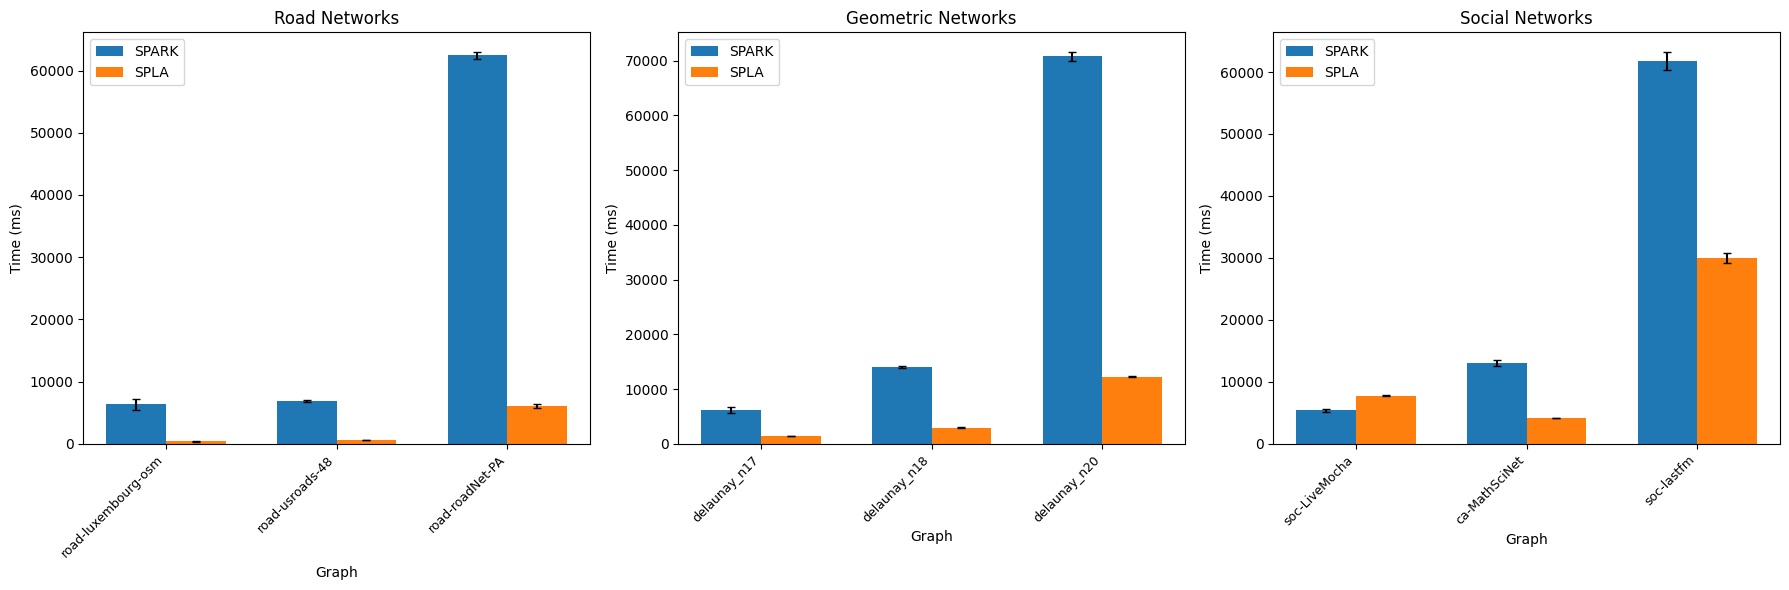

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

for idx, gtype in enumerate(["Road", "Geometric", "Social"]):
    ax = axes[idx]
    subset = summary[summary["graph_type"] == gtype].sort_values("vertices")
    
    graphs = subset["graph"].unique()
    x = np.arange(len(graphs))
    width = 0.35
    
    for i, lib in enumerate(["SPARK", "SPLA"]):
        lib_data = subset[subset["library"] == lib]
        times = []
        stds = []
        for g in graphs:
            row = lib_data[lib_data["graph"] == g]
            if len(row) > 0:
                times.append(row["mean_time_ms"].values[0])
                stds.append(row["std_time_ms"].values[0])
            else:
                times.append(0)
                stds.append(0)
        
        offset = -width/2 + i * width
        ax.bar(x + offset, times, width, yerr=stds, label=lib, capsize=3)
    
    ax.set_xlabel("Graph")
    ax.set_ylabel("Time (ms)")
    ax.set_title(f"{gtype} Networks")
    ax.set_xticks(x)
    ax.set_xticklabels(graphs, rotation=45, ha="right", fontsize=9)
    ax.legend()

plt.tight_layout()
plt.savefig(str(results_path / "comparison_by_graph_type.png"), dpi=150, bbox_inches="tight")
plt.show()

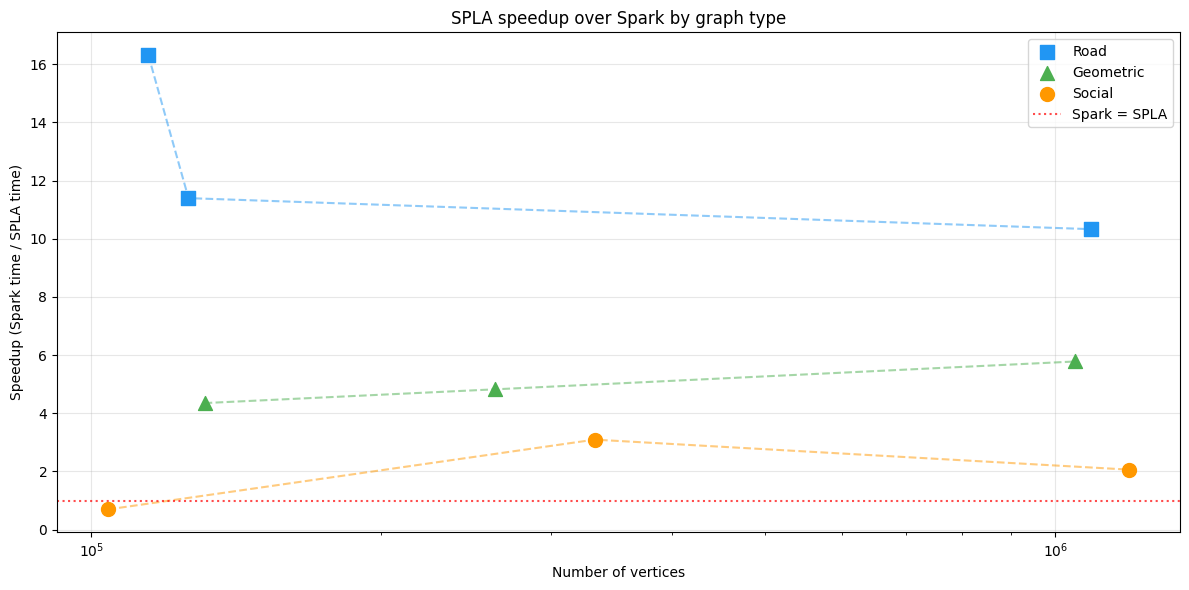

In [65]:
pivot = summary.pivot_table(
    index=["graph", "graph_type", "vertices"],
    columns="library",
    values="mean_time_ms"
).reset_index()

if "SPARK" in pivot.columns and "SPLA" in pivot.columns:
    pivot["speedup"] = pivot["SPARK"] / pivot["SPLA"]
    pivot = pivot.sort_values("vertices")
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    colors = {"Road": "#2196F3", "Geometric": "#4CAF50", "Social": "#FF9800"}
    markers = {"Road": "s", "Geometric": "^", "Social": "o"}
    
    for gtype in ["Road", "Geometric", "Social"]:
        subset = pivot[pivot["graph_type"] == gtype]
        ax.scatter(subset["vertices"], subset["speedup"],
                   c=colors[gtype], marker=markers[gtype], s=100, label=gtype, zorder=5)
        ax.plot(subset["vertices"], subset["speedup"],
                c=colors[gtype], linestyle="--", alpha=0.5)
    
    ax.axhline(y=1.0, color="red", linestyle=":", alpha=0.7, label="Spark = SPLA")
    ax.set_xlabel("Number of vertices")
    ax.set_ylabel("Speedup (Spark time / SPLA time)")
    ax.set_title("SPLA speedup over Spark by graph type")
    ax.set_xscale("log")
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(str(results_path / "speedup_by_graph_type.png"), dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Not enough data. Need both SPARK and SPLA results.")

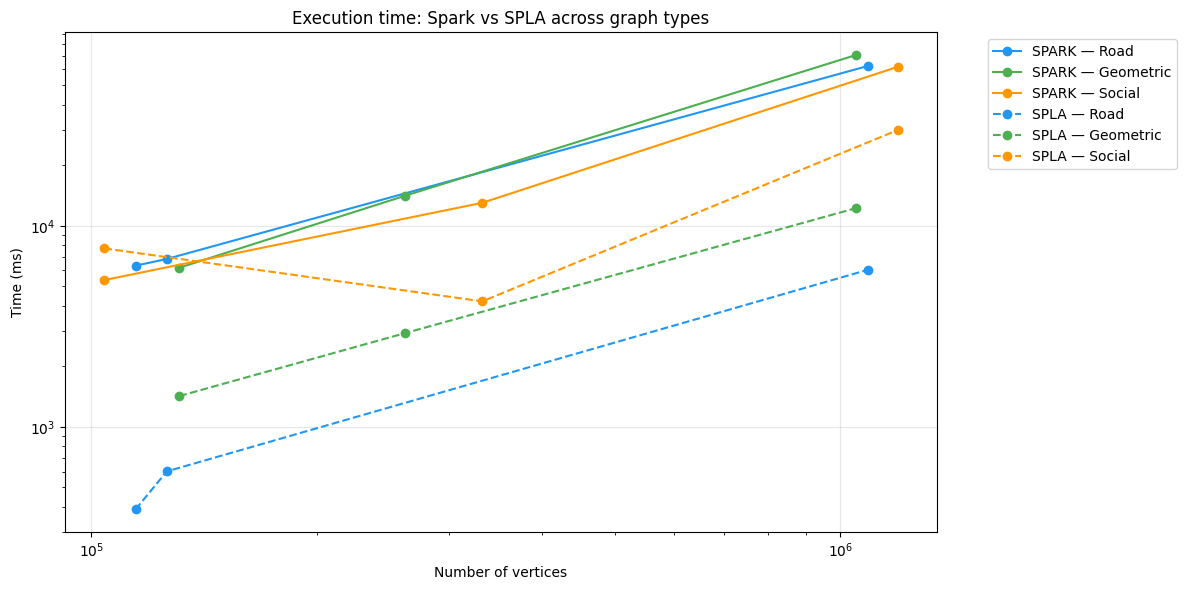

In [66]:
fig, ax = plt.subplots(figsize=(12, 6))

line_styles = {"SPARK": "-", "SPLA": "--"}
colors = {"Road": "#2196F3", "Geometric": "#4CAF50", "Social": "#FF9800"}

for lib in ["SPARK", "SPLA"]:
    for gtype in ["Road", "Geometric", "Social"]:
        subset = summary[(summary["library"] == lib) & (summary["graph_type"] == gtype)]
        subset = subset.sort_values("vertices")
        if len(subset) > 0:
            label = f"{lib} — {gtype}"
            ax.plot(subset["vertices"], subset["mean_time_ms"],
                    linestyle=line_styles[lib], color=colors[gtype],
                    marker="o", markersize=6, label=label)

ax.set_xlabel("Number of vertices")
ax.set_ylabel("Time (ms)")
ax.set_title("Execution time: Spark vs SPLA across graph types")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(results_path / "time_by_type_and_size.png"), dpi=150, bbox_inches="tight")
plt.show()

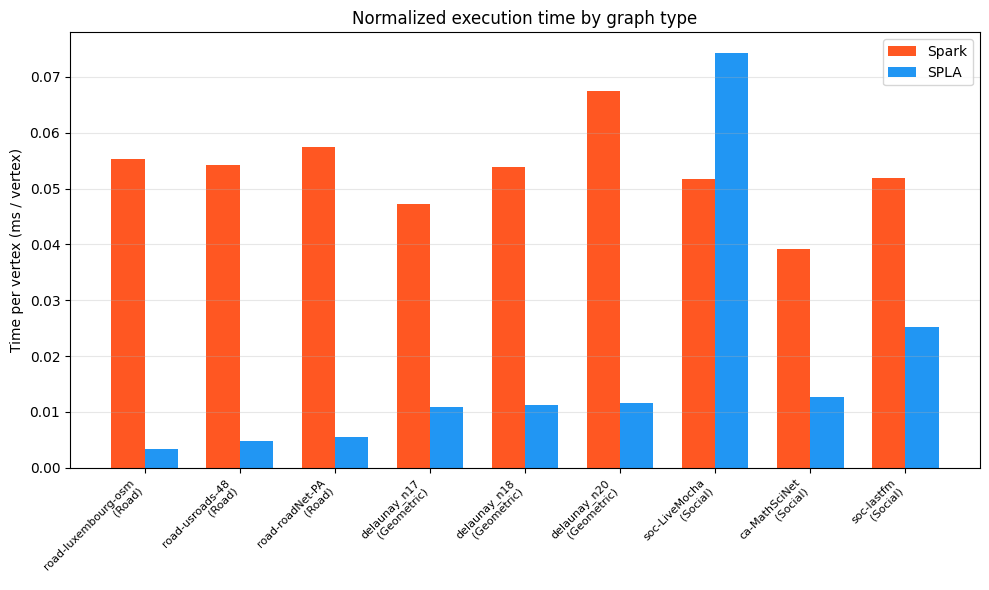

In [67]:
summary["time_per_vertex"] = summary["mean_time_ms"] / summary["vertices"]

fig, ax = plt.subplots(figsize=(10, 6))

x_labels = []
spark_vals = []
spla_vals = []

for gtype in ["Road", "Geometric", "Social"]:
    gtype_data = summary[summary["graph_type"] == gtype].sort_values("vertices")
    for graph_name in gtype_data["graph"].unique():
        spark_row = gtype_data[(gtype_data["graph"] == graph_name) & (gtype_data["library"] == "SPARK")]
        spla_row = gtype_data[(gtype_data["graph"] == graph_name) & (gtype_data["library"] == "SPLA")]
        
        if len(spark_row) > 0 and len(spla_row) > 0:
            x_labels.append(f"{graph_name}\n({gtype})")
            spark_vals.append(spark_row["time_per_vertex"].values[0])
            spla_vals.append(spla_row["time_per_vertex"].values[0])

x = np.arange(len(x_labels))
width = 0.35

ax.bar(x - width/2, spark_vals, width, label="Spark", color="#FF5722")
ax.bar(x + width/2, spla_vals, width, label="SPLA", color="#2196F3")

ax.set_ylabel("Time per vertex (ms / vertex)")
ax.set_title("Normalized execution time by graph type")
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=8)
ax.legend()
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(str(results_path / "time_per_vertex.png"), dpi=150, bbox_inches="tight")
plt.show()

## Step 8. Conclusions

Key observations:

1. **Graph type significantly affects relative performance** of Spark vs SPLA
2. **Road networks** (sparse, many iterations) — ...
3. **Geometric graphs** (triangulation, moderate) — ...
4. **Social graphs** (dense, few iterations) — ...

Fill in based on actual results.